# Linear Regression by scratch

In [13]:
# normal equation
# theta = (Xt X)^-1 Xt y
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
X = 2 * np.random.rand(100,1)
y = 4 + 3 * X + np.random.randn(100,1)

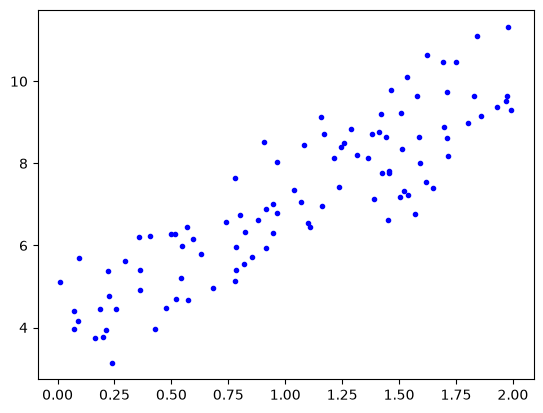

In [21]:
plt.plot(X,y,'b.')
plt.show()

In [15]:
X_b = np.c_[np.ones((100,1)),X]  # add x0 as 1 to all instances
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

In [16]:
theta_best

array([[4.00619854],
       [2.99174458]])

In [20]:
# use the theta best to predict values now : 
X_test = [[0],[2]]
X_test_b = np.c_[np.ones((2,1)),X_test]
y_predict = X_test_b.dot(theta_best)
y_predict

array([[4.00619854],
       [9.9896877 ]])

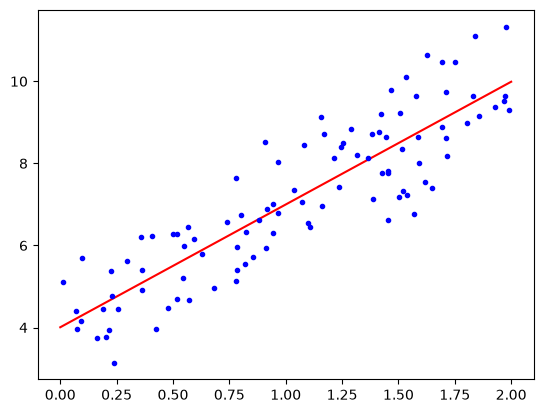

In [22]:
# now plot this line 
plt.plot(X_test,y_predict,'r-')
plt.plot(X,y,'b.')
plt.show()

In [24]:
# now predict the same but using the linear regression model by scikit learn 
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression() 
lin_reg.fit(X,y)
lin_predict = lin_reg.predict(X_test)
lin_predict

array([[4.00619854],
       [9.9896877 ]])

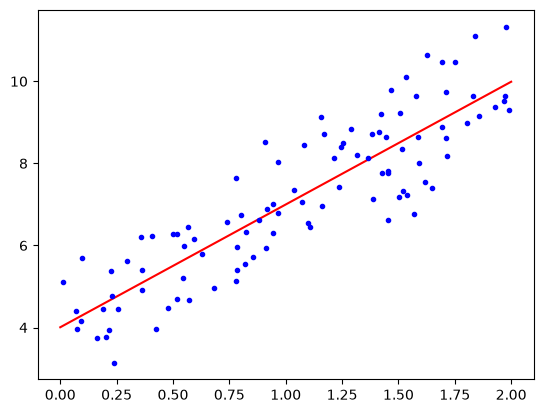

In [25]:
# now plot this line 
plt.plot(X_test,lin_predict,'r-')
plt.plot(X,y,'b.')
plt.show()

In [26]:
# normal equation fails whenever the data has more featuers than instances and whenever there exists similar features since it fails to find the best theta value hence Linear Regression model usese the SVD method by finding the pseudo inverse to calculate theta 
theta_best_svd, residuals, rank, s = np.linalg.lstsq(X_b, y, rcond=1e-6)
theta_best_svd

array([[4.00619854],
       [2.99174458]])

In [27]:
theta_best = np.linalg.pinv(X_b).dot(y)
theta_best

array([[4.00619854],
       [2.99174458]])

In [30]:
# batch Gradient Decent 
n_interations = 1000
theta = np.random.randn(2,1)
m = 100 #number of instances present in X
lr = 0.1
for _ in range(n_interations):
    gradient = 2/m * X_b.T.dot(X_b.dot(theta)-y)
    theta = theta - lr*gradient
theta

array([[4.00619854],
       [2.99174458]])

## Polynomial Regression

In [42]:
# if the data point don't form a straight path then it is difficult to use normal regression to get the best fit line
# we need to change the data by adding new features that are the powers of the previous feature
m = 100
X = 10 * np.random.rand(m,1) -3 
y = X**2 * 0.5 + X +2+ np.random.randn(m,1)

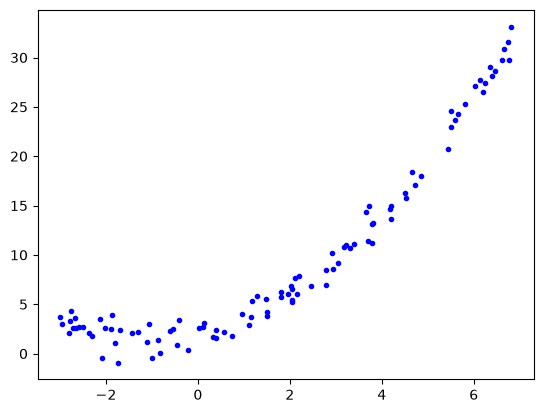

In [43]:
# now plot this line 
plt.plot(X,y,'b.')
plt.show()

In [82]:
from sklearn.preprocessing import PolynomialFeatures
poly_features = PolynomialFeatures(degree=2,include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0]

array([2.05560466])

In [85]:
X_poly[0]

array([2.05560466, 4.22551053])

In [83]:
lin_reg = LinearRegression() 
lin_reg.fit(X_poly,y)
X_test_poly = poly_features.transform(X_test)
lin_predict = lin_reg.predict(X_test_poly)

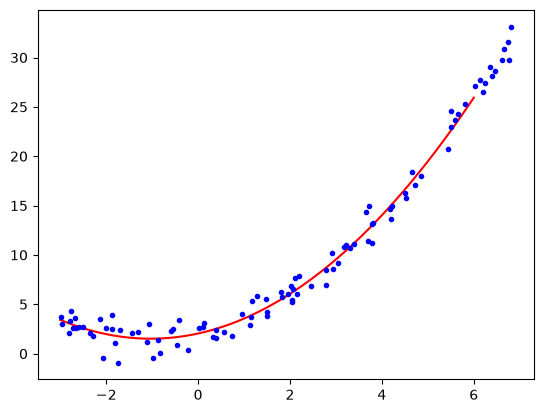

In [84]:
# now plot this line 
plt.plot(X_test,lin_predict,'r-')
plt.plot(X,y,'b.')
plt.show()

### load the iris dataset and train your model 

In [86]:
from sklearn import datasets
iris = datasets.load_iris() 
list(iris)

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [91]:
iris["feature_names"]

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

### First lets only train the model to guess the flower by petal width

In [103]:
X = iris["data"][:,3:] # get only petal width

In [104]:
iris["target_names"]

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [105]:
y = (iris["target"]==2).astype(int) # if iris virginica then 1 else 0

### use logistic regression to make the model

In [106]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression() 
log_reg.fit(X,y)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

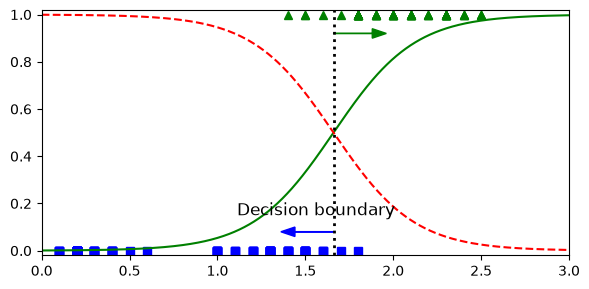

In [126]:
X_test = np.linspace(0,3,1000).reshape(-1,1)
y_proba = log_reg.predict_proba(X_test)
plt.figure(figsize=(6,3))
plt.plot(X[y == 0], y[y == 0], "bs", markersize=6)
plt.plot(X[y == 1], y[y == 1], "g^", markersize=6)
plt.plot(X_test,y_proba[:,1],'g-',label='Iris virginica')
plt.plot(X_test,y_proba[:,0],'r--',label='Not Iris virginica')

decision_boundary = X_test[y_proba[:, 1] >= 0.5][0,0]
plt.axvline(x=decision_boundary, color="k", linestyle=":", linewidth=2)
plt.text(decision_boundary - 0.1, 0.15, "Decision boundary", fontsize=12, color="k", ha="center")
plt.arrow(float(decision_boundary), 0.08, -0.3, 0, head_width=0.04, head_length=0.08, ec="b", fc="b", length_includes_head=True)
plt.arrow(float(decision_boundary), 0.92, 0.3, 0, head_width=0.04, head_length=0.08, ec="g", fc="g", length_includes_head=True)

plt.axis([0, 3, -0.02, 1.02])
plt.tight_layout()
plt.show()